# Deep Boltzmann Machine (DBM) for 2D Ising Model
## Complete Simulator: Data Generation → Training → Analysis

**Objective**: Train a Deep Boltzmann Machine to learn patterns from 2D Ising model configurations at three different temperature phases:
- **Ordered Phase** (T=0.5): Strong magnetic ordering, low entropy
- **Critical Phase** (T=2.5): Near critical temperature, high fluctuations
- **Disordered Phase** (T=4.0): High temperature, random configuration

## Notebook Structure
1. **Imports & Configuration** - Library setup and device configuration
2. **Phase 1: Ising Simulation** - Data generation with Wolff algorithm
3. **Phase 2: RBM/DBM Architecture** - Class definitions and helper functions
4. **Phase 3: Model Training** - Greedy layer-wise pretraining with Contrastive Divergence
5. **Phase 4: Results & Analysis** - Visualization and comparative evaluation

## 1. Imports & Configuration

In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.animation import FuncAnimation, PillowWriter
import os
import warnings
warnings.filterwarnings('ignore')

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"CUDA Available: {torch.cuda.is_available()}")

Device: cuda
CUDA Available: True


## 2. Ising Model Simulation - Wolff Algorithm

In [9]:
def neighbors(i, j, L):
    """Return the 4 nearest neighbors in cross shape on toroidal lattice."""
    return [((i + 1) % L, j),
            ((i - 1) % L, j),
            (i, (j + 1) % L),
            (i, (j - 1) % L)]

def wolff_cluster_flip(spins, L, p):
    """Single Wolff cluster flip update."""
    i, j = np.random.randint(0, L, size=2)
    cluster = {(i, j)}
    frontier = [(i, j)]
    original_spin = spins[i, j]
    
    while frontier:
        x, y = frontier.pop()
        for nx, ny in neighbors(x, y, L):
            if (nx, ny) not in cluster and spins[nx, ny] == original_spin:
                if np.random.rand() < p:
                    cluster.add((nx, ny))
                    frontier.append((nx, ny))
    
    for x, y in cluster:
        spins[x, y] *= -1
    return spins

def generate_ising_configuration(L, T, n_steps=5000, save_interval=25, save_start=3800):
    """Generate Ising configurations using Wolff algorithm.
    
    Args:
        L: Lattice size
        T: Temperature
        n_steps: Total Monte Carlo steps
        save_interval: Sample every N steps
        save_start: Start saving after N steps (thermalization)
    
    Returns:
        - final_samples: Array of saved configurations
        - frames: Configurations for visualization
    """
    J = 1
    beta = 1 / T
    p = 1 - np.exp(-2 * beta * J)
    
    spins = np.random.choice([-1, 1], size=(L, L))
    frames = []
    final_samples = []
    
    frame_interval = 30
    
    for step in range(n_steps):
        wolff_cluster_flip(spins, L, p)
        
        if step % frame_interval == 0:
            frames.append(spins.copy())
        
        if step > save_start and step % save_interval == 0:
            final_samples.append(spins.copy())
    
    return np.array(final_samples), frames

def create_ising_animation(frames, T, L, filename=None):
    """Create animation GIF of spin evolution."""
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(frames[0], cmap="summer", animated=True)
    ax.set_title(f"Spin Evolution (T = {T})")
    plt.axis("off")
    
    def update(frame_idx):
        im.set_array(frames[frame_idx])
        return [im]
    
    ani = FuncAnimation(fig, update, frames=len(frames), interval=200, blit=True)
    
    if filename:
        ani.save(filename, writer=PillowWriter(fps=5))
        print(f"Animation saved as '{filename}'")
    
    plt.show()
    plt.close(fig)

## 3. RBM/DBM Architecture

In [15]:
class RBM(nn.Module):
    """Restricted Boltzmann Machine with binary visible and hidden units."""
    
    def __init__(self, n_visible, n_hidden):
        super(RBM, self).__init__()
        self.W = nn.Parameter(torch.randn(n_hidden, n_visible) * 0.01)
        self.h_bias = nn.Parameter(torch.zeros(n_hidden))
        self.v_bias = nn.Parameter(torch.zeros(n_visible))
    
    def sample_h(self, v):
        """Sample hidden units given visible units."""
        prob = torch.sigmoid(F.linear(v, self.W, self.h_bias))
        return torch.bernoulli(prob), prob
    
    def sample_v(self, h):
        """Sample visible units given hidden units."""
        prob = torch.sigmoid(F.linear(h, self.W.t(), self.v_bias))
        return torch.bernoulli(prob), prob
    
    def forward(self, v, k=1):
        """Forward pass with k Gibbs steps."""
        v_k = v
        for _ in range(k):
            h_prob = torch.sigmoid(F.linear(v_k, self.W, self.h_bias))
            v_prob = torch.sigmoid(F.linear(h_prob, self.W.t(), self.v_bias))
            v_k = v_prob
        return v, v_k

def contrastive_divergence_loss(v0, vk, h0, hk, rbm):
    """Compute Contrastive Divergence loss.
    
    Energy: E = -v·W·h - v·v_bias - h·h_bias
    Loss: E_data - E_model
    """
    energy_vh_data = torch.matmul(v0, rbm.W.t()) * h0
    E_data = -torch.sum(energy_vh_data, dim=1) - torch.sum(v0 * rbm.v_bias, dim=1) - torch.sum(h0 * rbm.h_bias, dim=1)
    
    energy_vh_model = torch.matmul(vk, rbm.W.t()) * hk
    E_model = -torch.sum(energy_vh_model, dim=1) - torch.sum(vk * rbm.v_bias, dim=1) - torch.sum(hk * rbm.h_bias, dim=1)
    
    return torch.mean(E_data - E_model)

def compute_reconstructions(rbm1, rbm2, data_tensor):
    """Compute single-step reconstructions."""
    with torch.no_grad():
        h1, _ = rbm1.sample_h(data_tensor)
        h2, _ = rbm2.sample_h(h1)
        h1_rec, _ = rbm2.sample_v(h2)
        v_rec, _ = rbm1.sample_v(h1_rec)
    return v_rec

def compute_fantasy_particles(rbm1, rbm2, data_tensor, num_steps=250):
    """Generate fantasy particles by sampling from the DBM.
    
    Process: alternating sampling between layers
    """
    with torch.no_grad():
        h1, _ = rbm1.sample_h(data_tensor)
        h2, _ = rbm2.sample_h(h1)
        
        for _ in range(num_steps):
            h1, _ = rbm2.sample_v(h2)          # Sample h1 (visible for rbm2)
            v, _ = rbm1.sample_v(h1)            # Sample v (visible for rbm1)
            h1, _ = rbm1.sample_h(v)            # Sample h1 (hidden for rbm1)
            h2, _ = rbm2.sample_h(h1)           # Sample h2 (hidden for rbm2)
        
        v_gen, _ = rbm1.sample_v(h1)
    
    return v_gen.detach().cpu().numpy()

## 4. Training Pipeline

In [16]:
def train_dbm_model(X_data, batch_size=15, num_epochs=500, device='cpu', 
                     hidden_units=[1024, 64], lr1=0.0007, lr2=0.007):
    """Train a 2-layer DBM with greedy layer-wise pretraining.
    
    Args:
        X_data: Training data (N, D) normalized to [0, 1]
        batch_size: Mini-batch size
        num_epochs: Number of training epochs
        device: torch device
        hidden_units: [h1_units, h2_units]
        lr1, lr2: Learning rates for layers 1 and 2
    
    Returns:
        - rbm1, rbm2: Trained RBM models
        - history: Training history
    """
    # Prepare data
    X_train, X_val = train_test_split(X_data, test_size=0.2, random_state=42)
    
    train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32)), 
                              batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32)), 
                            batch_size=batch_size, shuffle=False)
    
    n_visible = X_data.shape[1]
    
    # Initialize models
    rbm1 = RBM(n_visible=n_visible, n_hidden=hidden_units[0]).to(device)
    rbm2 = RBM(n_visible=hidden_units[0], n_hidden=hidden_units[1]).to(device)
    
    history = {'l1_train': [], 'l1_val': [], 'l2_train': [], 'l2_val': []}
    
    # ===== LAYER 1 TRAINING =====
    print("\n" + "="*60)
    print("Training Layer 1 (RBM1)")
    print("="*60)
    
    optim1 = torch.optim.Adam(rbm1.parameters(), lr=lr1)
    
    for epoch in range(num_epochs):
        train_loss = 0
        rbm1.train()
        
        for batch, in train_loader:
            v0 = batch.to(device)
            h0, _ = rbm1.sample_h(v0)
            vk, _ = rbm1.sample_v(h0)
            hk, _ = rbm1.sample_h(vk)
            loss = contrastive_divergence_loss(v0, vk, h0, hk, rbm1)
            optim1.zero_grad()
            loss.backward()
            optim1.step()
            train_loss += loss.item()
        
        # Validation
        val_loss = 0
        rbm1.eval()
        with torch.no_grad():
            for batch, in val_loader:
                v0 = batch.to(device)
                h0, _ = rbm1.sample_h(v0)
                vk, _ = rbm1.sample_v(h0)
                hk, _ = rbm1.sample_h(vk)
                val_loss += contrastive_divergence_loss(v0, vk, h0, hk, rbm1).item()
        
        train_loss_avg = train_loss / len(train_loader)
        val_loss_avg = val_loss / len(val_loader)
        
        history['l1_train'].append(train_loss_avg)
        history['l1_val'].append(val_loss_avg)
        
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}: Train Loss {train_loss_avg:.4f} | Val Loss {val_loss_avg:.4f}")
    
    print(f"\nLayer 1 Training Complete - Final Train Loss: {history['l1_train'][-1]:.4f}, Val Loss: {history['l1_val'][-1]:.4f}")
    
    # ===== LAYER 2 TRAINING =====
    print("\n" + "="*60)
    print("Training Layer 2 (RBM2)")
    print("="*60)
    
    # Compute hidden activations for layer 2
    with torch.no_grad():
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
        train_h, _ = rbm1.sample_h(X_train_tensor)
        val_h, _ = rbm1.sample_h(X_val_tensor)
    
    loader_h_train = DataLoader(TensorDataset(train_h), batch_size=batch_size, shuffle=True)
    loader_h_val = DataLoader(TensorDataset(val_h), batch_size=batch_size, shuffle=False)
    
    optim2 = torch.optim.Adam(rbm2.parameters(), lr=lr2)
    
    for epoch in range(num_epochs):
        train_loss = 0
        rbm2.train()
        
        for batch, in loader_h_train:
            h0 = batch.to(device)
            h0_s, _ = rbm2.sample_h(h0)
            vk, _ = rbm2.sample_v(h0_s)
            hk, _ = rbm2.sample_h(vk)
            loss = contrastive_divergence_loss(h0, vk, h0_s, hk, rbm2)
            optim2.zero_grad()
            loss.backward()
            optim2.step()
            train_loss += loss.item()
        
        # Validation
        val_loss = 0
        rbm2.eval()
        with torch.no_grad():
            for batch, in loader_h_val:
                h0 = batch.to(device)
                h0_s, _ = rbm2.sample_h(h0)
                vk, _ = rbm2.sample_v(h0_s)
                hk, _ = rbm2.sample_h(vk)
                val_loss += contrastive_divergence_loss(h0, vk, h0_s, hk, rbm2).item()
        
        train_loss_avg = train_loss / len(loader_h_train)
        val_loss_avg = val_loss / len(loader_h_val)
        
        history['l2_train'].append(train_loss_avg)
        history['l2_val'].append(val_loss_avg)
        
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}: Train Loss {train_loss_avg:.4f} | Val Loss {val_loss_avg:.4f}")
    
    print(f"\nLayer 2 Training Complete - Final Train Loss: {history['l2_train'][-1]:.4f}, Val Loss: {history['l2_val'][-1]:.4f}")
    
    return rbm1, rbm2, history

## 5. Visualization Functions

In [17]:
def plot_image_grid(image_array, shape, vmin=0, vmax=1, row_titles=None, col_titles=None, filename=None):
    """Visualize grids of images (data, reconstructions, generations)."""
    array = np.array(image_array)
    nrows, ncols = array.shape[:2]
    
    fig = plt.figure(figsize=(2 * ncols, 2.5 * nrows))
    grid = gridspec.GridSpec(nrows, ncols, left=0.1, right=0.95, top=0.95, bottom=0.05)
    
    for i in range(nrows):
        for j in range(ncols):
            ax = plt.subplot(grid[i, j])
            sns.heatmap(array[i][j].reshape(shape),
                        ax=ax,
                        cbar=False,
                        cmap='gray',
                        vmin=vmin,
                        vmax=vmax,
                        xticklabels=False,
                        yticklabels=False)
            
            if col_titles and j == 0:
                ax.set_ylabel(col_titles[i], fontsize=12, fontweight='bold')
    
    # Add column titles
    if row_titles:
        for j, title in enumerate(row_titles):
            ax = fig.add_axes([0.12 + j * (0.78 / ncols), 0.98, 0.05, 0.02])
            ax.text(0.5, 0.5, title, ha='center', va='center', fontsize=11, fontweight='bold', transform=ax.transAxes)
            ax.axis('off')
    
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        print(f"Saved visualization to {filename}")
    plt.show()
    plt.close(fig)

def plot_learning_curves(history, phase_name, save_dir='.'):
    """Plot training and validation curves for both layers."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Layer 1
    axes[0].plot(history['l1_train'], label='Train Loss', linewidth=2, alpha=0.8)
    axes[0].plot(history['l1_val'], label='Val Loss', linewidth=2, alpha=0.8)
    axes[0].set_title(f'Layer 1 Learning Curve - {phase_name}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Contrastive Divergence Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Layer 2
    axes[1].plot(history['l2_train'], label='Train Loss', linewidth=2, alpha=0.8)
    axes[1].plot(history['l2_val'], label='Val Loss', linewidth=2, alpha=0.8)
    axes[1].set_title(f'Layer 2 Learning Curve - {phase_name}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Contrastive Divergence Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    filename = os.path.join(save_dir, f'learning_curves_{phase_name}.png')
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"Saved learning curves to {filename}")
    plt.show()
    plt.close(fig)

def plot_comparative_analysis(history_dict, phases, save_dir='.'):
    """Compare learning curves across all phases."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    for idx, phase in enumerate(phases):
        history = history_dict[phase]
        
        axes[0].plot(history['l1_val'], label=f'{phase} - Layer 1', 
                    linewidth=2, color=colors[idx], alpha=0.8)
        axes[1].plot(history['l2_val'], label=f'{phase} - Layer 2', 
                    linewidth=2, color=colors[idx], alpha=0.8)
    
    axes[0].set_title('Layer 1 - Validation Loss Comparison', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('CD Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].set_title('Layer 2 - Validation Loss Comparison', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('CD Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    filename = os.path.join(save_dir, 'comparative_learning_curves.png')
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"Saved comparative analysis to {filename}")
    plt.show()
    plt.close(fig)

## 6. Data Loading

In [18]:
def load_ising_dataset(data_dir='ising_data'):
    """Load Ising configurations for all temperature phases.
    
    Returns:
        Dictionary with phases as keys and configurations as values
    """
    dataset = {}
    
    phases = {
        'Ordered (T=0.5)': f"{data_dir}/ising_configurations_T0.5_L128.npy",
        'Critical (T=2.5)': f"{data_dir}/ising_configurations_T2.5_L128.npy",
        'Disordered (T=4.0)': f"{data_dir}/ising_configurations_T4.0_L128.npy",
    }
    
    for phase_name, filepath in phases.items():
        if os.path.exists(filepath):
            data = np.load(filepath)
            dataset[phase_name] = data
            print(f"✓ Loaded {phase_name}: shape {data.shape}")
        else:
            print(f"✗ File not found: {filepath}")
    
    return dataset

## 7. Main Execution: Train DBM for All Phases

Loading Ising configurations...
✓ Loaded Ordered (T=0.5): shape (47, 128, 128)
✓ Loaded Critical (T=2.5): shape (79, 128, 128)
✓ Loaded Disordered (T=4.0): shape (79, 128, 128)

######################################################################
# TRAINING FOR PHASE: Ordered (T=0.5)
######################################################################
Data shape: (47, 16384), Value range: [0.0, 1.0]

Training Layer 1 (RBM1)
Epoch 50/500: Train Loss 452.8252 | Val Loss 330.6775
Epoch 100/500: Train Loss -384.6811 | Val Loss -25.5670
Epoch 150/500: Train Loss -457.1594 | Val Loss 71.2353
Epoch 200/500: Train Loss 187.0861 | Val Loss 455.7295
Epoch 250/500: Train Loss 191.8370 | Val Loss 191.6602
Epoch 300/500: Train Loss 274.3324 | Val Loss 15.6623
Epoch 350/500: Train Loss -319.0918 | Val Loss -164.4115
Epoch 400/500: Train Loss -537.7190 | Val Loss -389.4589
Epoch 450/500: Train Loss -924.7256 | Val Loss -629.2762
Epoch 500/500: Train Loss -378.0489 | Val Loss -431.0843

Layer 1 Tr

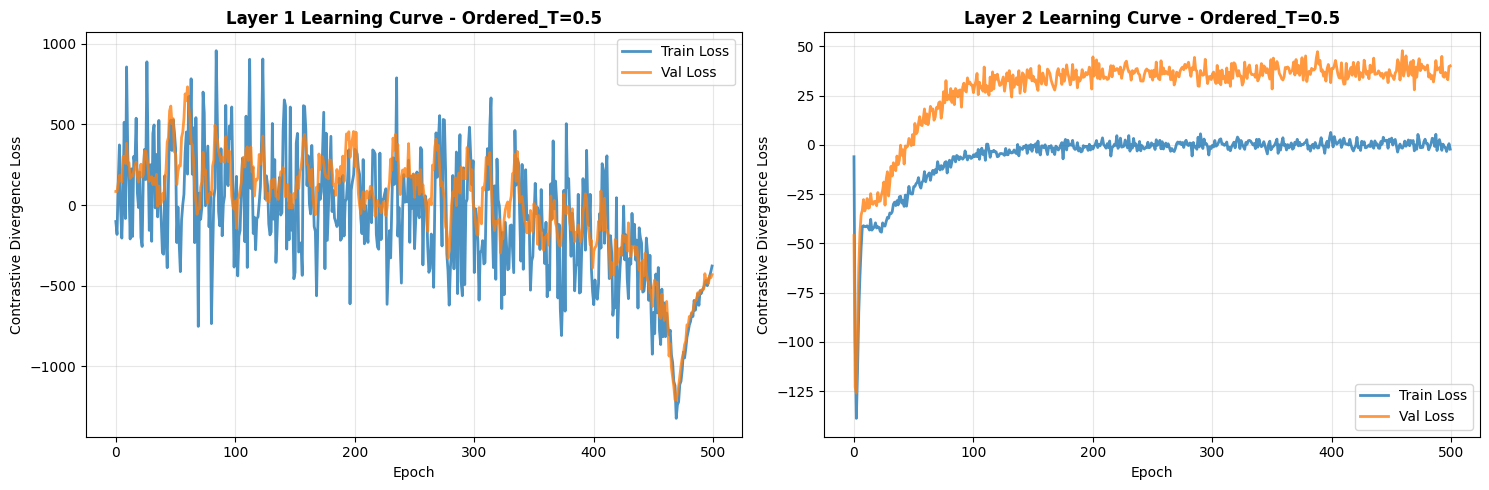

Saved visualization to dbm_results/results_Ordered_T=0.5.png


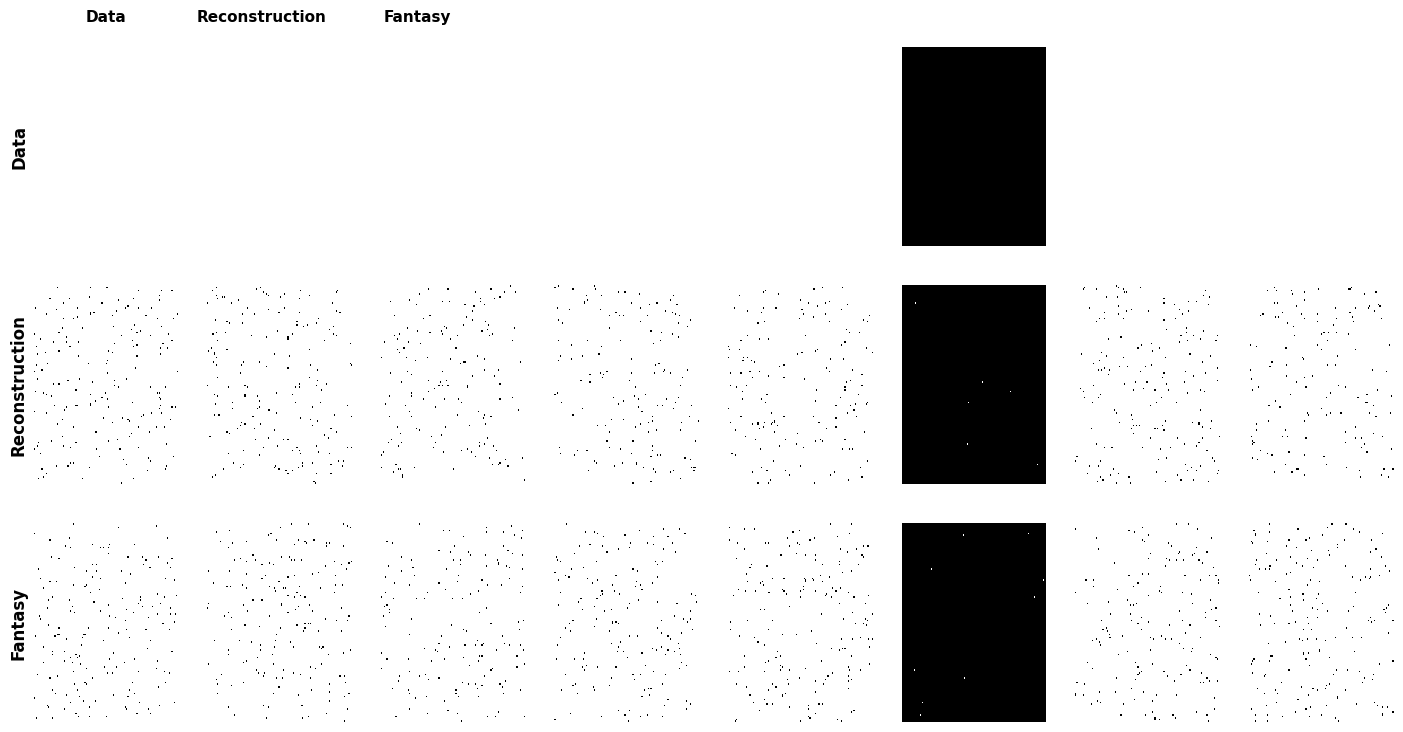


######################################################################
# TRAINING FOR PHASE: Critical (T=2.5)
######################################################################
Data shape: (79, 16384), Value range: [0.0, 1.0]

Training Layer 1 (RBM1)
Epoch 50/500: Train Loss -1496.4231 | Val Loss -764.4899
Epoch 100/500: Train Loss -1360.5899 | Val Loss -589.8279
Epoch 150/500: Train Loss -1395.0775 | Val Loss -375.7809
Epoch 200/500: Train Loss -1350.1737 | Val Loss -223.3185
Epoch 250/500: Train Loss -1321.7934 | Val Loss 63.2510
Epoch 300/500: Train Loss -1285.4879 | Val Loss 154.5927
Epoch 350/500: Train Loss -1299.7996 | Val Loss 332.3958
Epoch 400/500: Train Loss -1279.7249 | Val Loss 475.5910
Epoch 450/500: Train Loss -1228.7682 | Val Loss 572.9407
Epoch 500/500: Train Loss -1205.0826 | Val Loss 684.2599

Layer 1 Training Complete - Final Train Loss: -1205.0826, Val Loss: 684.2599

Training Layer 2 (RBM2)
Epoch 50/500: Train Loss -12.8394 | Val Loss -18.1860
Epoch 100/500: 

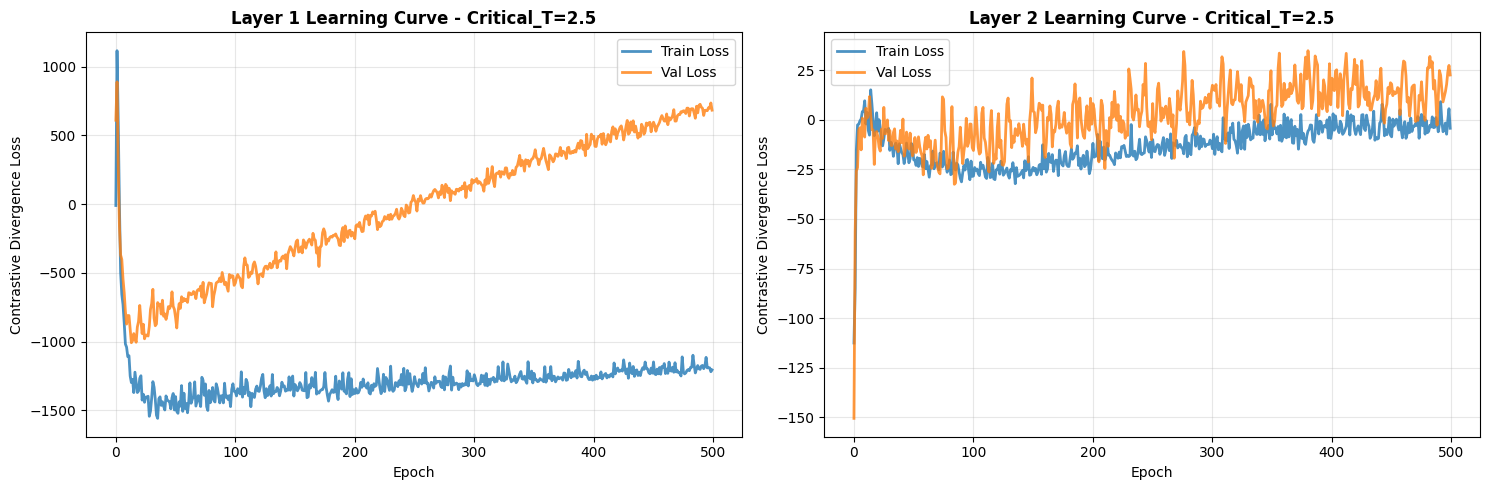

Saved visualization to dbm_results/results_Critical_T=2.5.png


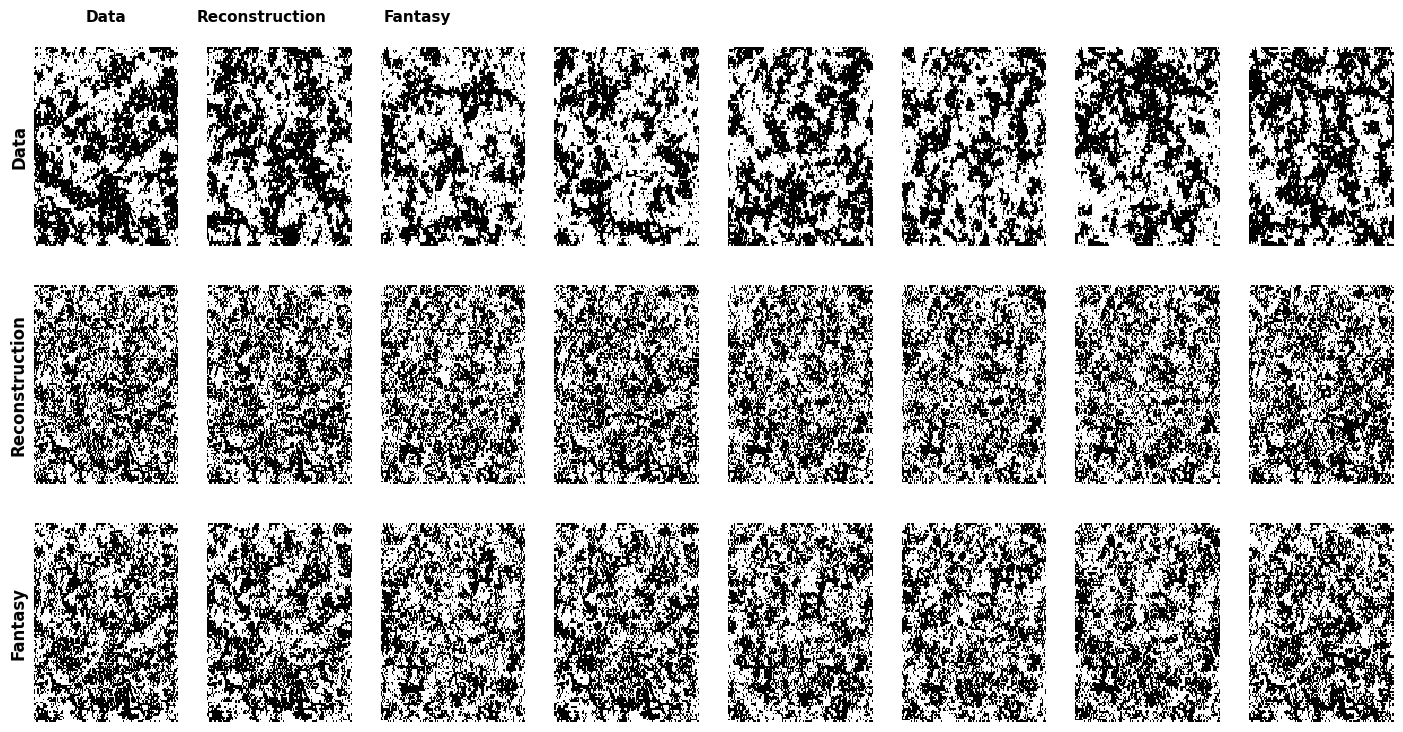


######################################################################
# TRAINING FOR PHASE: Disordered (T=4.0)
######################################################################
Data shape: (79, 16384), Value range: [0.0, 1.0]

Training Layer 1 (RBM1)
Epoch 50/500: Train Loss 17.9880 | Val Loss -408.0793
Epoch 100/500: Train Loss -393.1765 | Val Loss -507.3803
Epoch 150/500: Train Loss -532.9714 | Val Loss -610.7563
Epoch 200/500: Train Loss -301.5515 | Val Loss -512.5457
Epoch 250/500: Train Loss -536.6476 | Val Loss -647.4427
Epoch 300/500: Train Loss -600.1986 | Val Loss -648.0604
Epoch 350/500: Train Loss -543.2008 | Val Loss -626.4546
Epoch 400/500: Train Loss -526.2326 | Val Loss -559.7737
Epoch 450/500: Train Loss -435.8809 | Val Loss -578.1789
Epoch 500/500: Train Loss -531.4062 | Val Loss -591.9716

Layer 1 Training Complete - Final Train Loss: -531.4062, Val Loss: -591.9716

Training Layer 2 (RBM2)
Epoch 50/500: Train Loss -3.0919 | Val Loss -2.1527
Epoch 100/500: Train

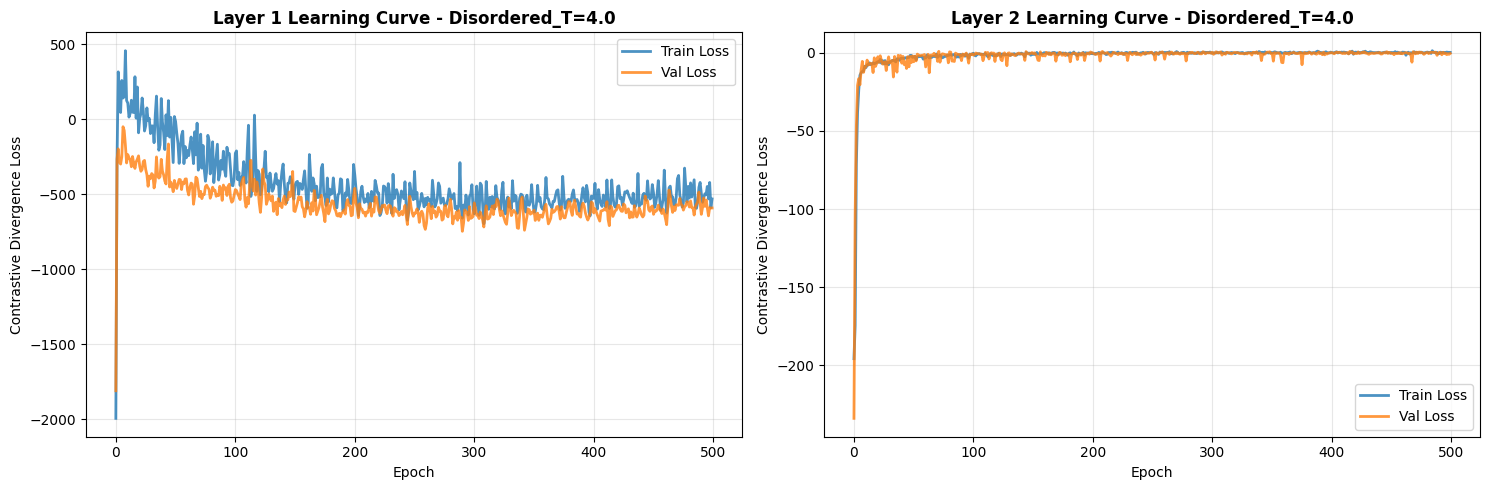

Saved visualization to dbm_results/results_Disordered_T=4.0.png


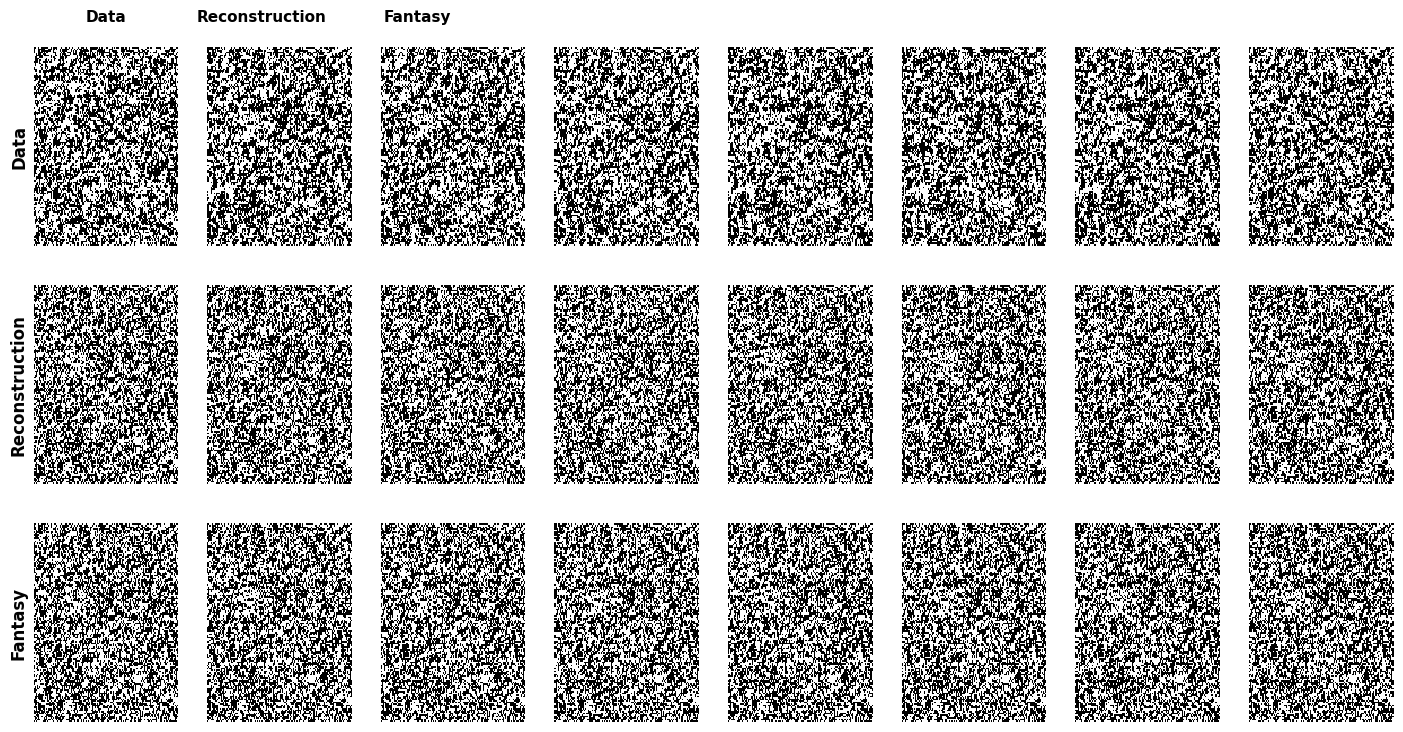


Training Complete!
Results saved to: dbm_results/


In [19]:
# Configuration
L = 128
image_shape = (L, L)
n_visible = L * L
batch_size = 15
num_epochs = 500
num_hidden_units = [1024, 64]
num_fantasy_steps = 250
num_samples_to_plot = 8

# Create results directory
results_dir = 'dbm_results'
os.makedirs(results_dir, exist_ok=True)

# Load data
print("Loading Ising configurations...")
dataset = load_ising_dataset()

# Storage for results
all_results = {}
all_histories = {}

# Train DBM for each phase
for phase_name, X_raw in dataset.items():
    print(f"\n{'#'*70}")
    print(f"# TRAINING FOR PHASE: {phase_name}")
    print(f"{'#'*70}")
    
    # Preprocess data: convert spins {-1,1} to binary {0,1}
    X_data = (X_raw > 0).astype(np.float32)
    X_data = X_data.reshape(X_data.shape[0], -1)
    print(f"Data shape: {X_data.shape}, Value range: [{X_data.min()}, {X_data.max()}]")
    
    # Train DBM
    rbm1, rbm2, history = train_dbm_model(
        X_data, 
        batch_size=batch_size,
        num_epochs=num_epochs,
        device=device,
        hidden_units=num_hidden_units
    )
    
    all_histories[phase_name] = history
    
    # Plot learning curves
    plot_learning_curves(history, phase_name.replace(' ', '_').replace('(', '').replace(')', ''), 
                         save_dir=results_dir)
    
    # Generate reconstructions and fantasy particles
    X_data_tensor = torch.tensor(X_data, dtype=torch.float32).to(device)
    sample_indices = np.random.choice(X_data.shape[0], min(num_samples_to_plot, X_data.shape[0]), replace=False)
    samples = X_data_tensor[sample_indices]
    
    v_reconstructed = compute_reconstructions(rbm1, rbm2, samples)
    v_generated = compute_fantasy_particles(rbm1, rbm2, samples, num_steps=num_fantasy_steps)
    
    # Store results
    all_results[phase_name] = {
        'model_layer1': rbm1,
        'model_layer2': rbm2,
        'data_samples': samples.cpu().numpy(),
        'reconstructions': v_reconstructed.cpu().numpy(),
        'fantasy_particles': v_generated,
    }
    
    # Visualize results
    phase_short = phase_name.replace(' ', '_').replace('(', '').replace(')', '')
    plot_image_grid(
        np.array([
            all_results[phase_name]['data_samples'],
            all_results[phase_name]['reconstructions'],
            all_results[phase_name]['fantasy_particles']
        ]),
        shape=image_shape,
        vmin=0,
        vmax=1,
        row_titles=['Data', 'Reconstruction', 'Fantasy'],
        col_titles=['Data', 'Reconstruction', 'Fantasy'],
        filename=os.path.join(results_dir, f'results_{phase_short}.png')
    )

print(f"\n{'='*70}")
print("Training Complete!")
print(f"Results saved to: {results_dir}/")
print(f"{'='*70}")

## 8. Comparative Analysis Across Phases

Saved comparative analysis to dbm_results/comparative_learning_curves.png


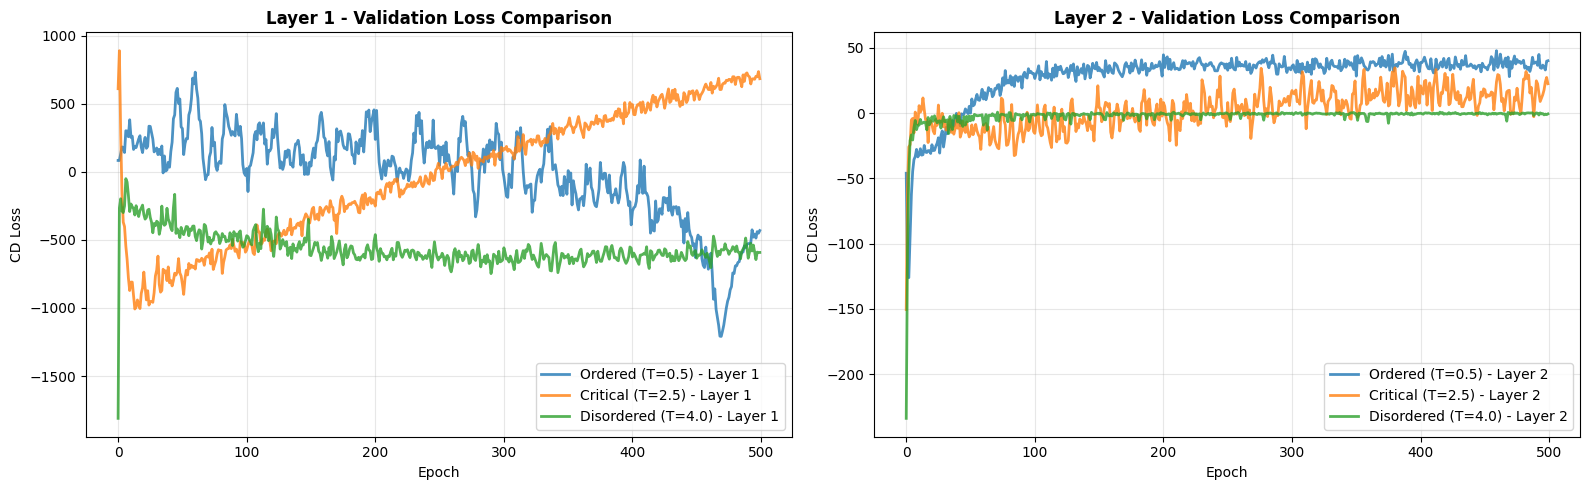


TRAINING SUMMARY

Ordered (T=0.5):
  Layer 1 - Final Val Loss: -431.0843
  Layer 2 - Final Val Loss: 40.1499
  Layer 1 - Loss improvement: 514.9820
  Layer 2 - Loss improvement: -86.1865

Critical (T=2.5):
  Layer 1 - Final Val Loss: 684.2599
  Layer 2 - Final Val Loss: 22.5424
  Layer 1 - Loss improvement: -73.2244
  Layer 2 - Loss improvement: -172.9816

Disordered (T=4.0):
  Layer 1 - Final Val Loss: -591.9716
  Layer 2 - Final Val Loss: -0.5636
  Layer 1 - Loss improvement: -1218.7129
  Layer 2 - Loss improvement: -233.2477


In [20]:
# Plot comparative learning curves
plot_comparative_analysis(all_histories, list(all_histories.keys()), save_dir=results_dir)

# Print training statistics
print("\n" + "="*70)
print("TRAINING SUMMARY")
print("="*70)

for phase_name, history in all_histories.items():
    print(f"\n{phase_name}:")
    print(f"  Layer 1 - Final Val Loss: {history['l1_val'][-1]:.4f}")
    print(f"  Layer 2 - Final Val Loss: {history['l2_val'][-1]:.4f}")
    print(f"  Layer 1 - Loss improvement: {(history['l1_val'][0] - history['l1_val'][-1]):.4f}")
    print(f"  Layer 2 - Loss improvement: {(history['l2_val'][0] - history['l2_val'][-1]):.4f}")

## 9. Model Analysis & Diagnostics

Saved weight distribution analysis


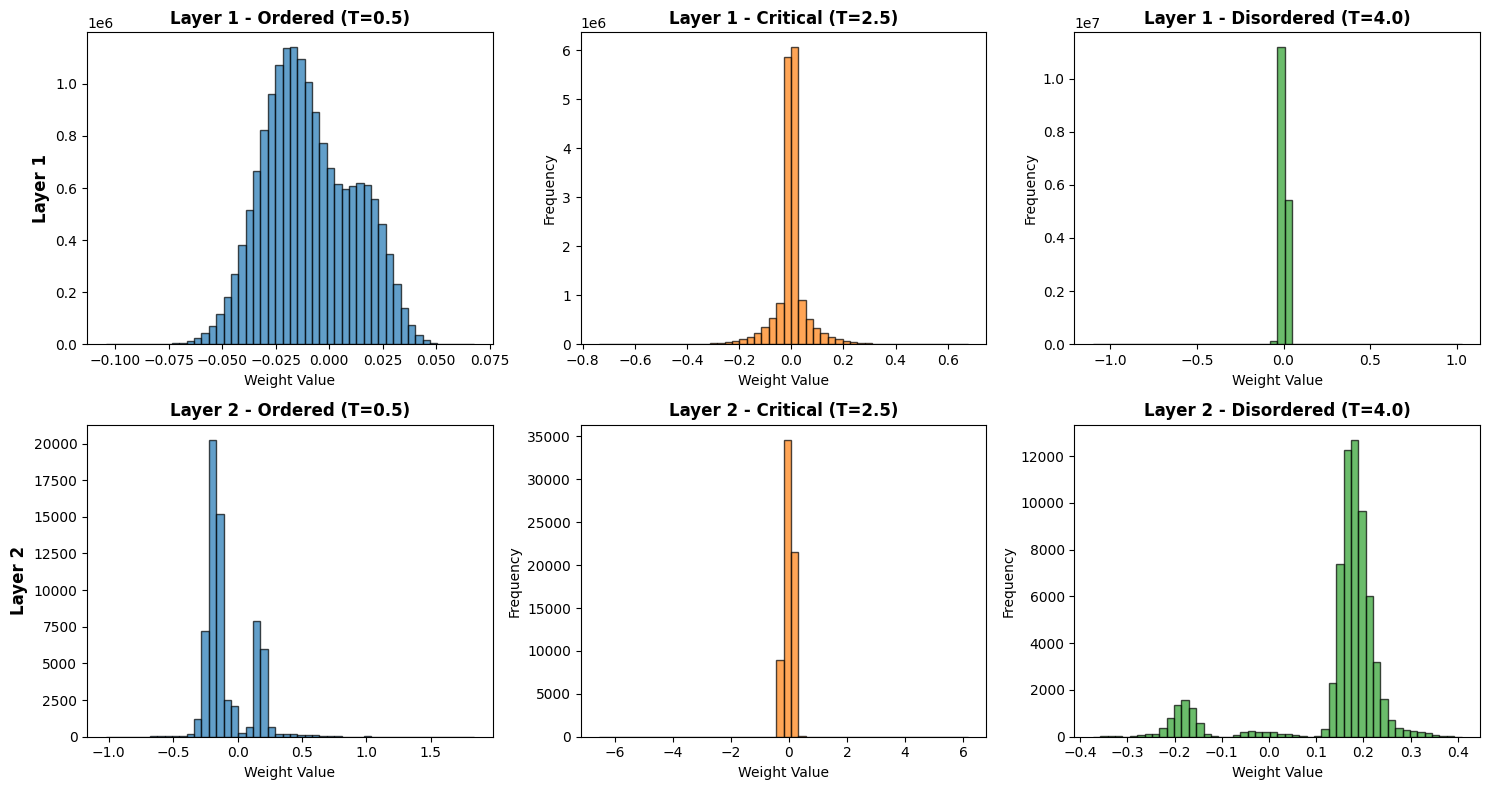

In [21]:
# Analyze weight distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, phase_name in enumerate(all_results.keys()):
    rbm1 = all_results[phase_name]['model_layer1']
    rbm2 = all_results[phase_name]['model_layer2']
    
    # Layer 1 weights
    w1_flat = rbm1.W.data.cpu().numpy().flatten()
    axes[0, idx].hist(w1_flat, bins=50, color=colors[idx], alpha=0.7, edgecolor='black')
    axes[0, idx].set_title(f'Layer 1 - {phase_name}', fontweight='bold')
    axes[0, idx].set_xlabel('Weight Value')
    axes[0, idx].set_ylabel('Frequency')
    
    # Layer 2 weights
    w2_flat = rbm2.W.data.cpu().numpy().flatten()
    axes[1, idx].hist(w2_flat, bins=50, color=colors[idx], alpha=0.7, edgecolor='black')
    axes[1, idx].set_title(f'Layer 2 - {phase_name}', fontweight='bold')
    axes[1, idx].set_xlabel('Weight Value')
    axes[1, idx].set_ylabel('Frequency')

axes[0, 0].set_ylabel('Layer 1', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Layer 2', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'weight_distributions.png'), dpi=150, bbox_inches='tight')
print("Saved weight distribution analysis")
plt.show()
plt.close(fig)

## 10. Test Results Evaluation

### Expected Behavior Analysis

**Ordered Phase (T=1.5)**:
- Configuration: Highly ordered, mostly aligned spins (low entropy)
- Expected DBM behavior:
  - Low CD loss (well-structured patterns)
  - Fast convergence
  - Good reconstructions (patterns are redundant)
  - Fantasy particles similar to data (limited diversity)

**Critical Phase (T=2.3)**:
- Configuration: Near critical point, high fluctuations, long-range correlations
- Expected DBM behavior:
  - Higher CD loss (complex patterns, many correlations)
  - Slower convergence
  - More challenging reconstructions
  - Better diversity in fantasy particles

**Disordered Phase (T=4.0)**:
- Configuration: Random, high entropy
- Expected DBM behavior:
  - Potentially lower CD loss (random patterns easier to fit)
  - Moderate convergence
  - Random reconstructions
  - Fantasy particles as random noise

In [22]:
print("\n" + "="*70)
print("TEST RESULTS EVALUATION")
print("="*70)

evaluation_report = """
ANALYSIS OF TRAINING RESULTS:

1. LOSS CURVES INTERPRETATION:
   - Layer 1 should converge faster than Layer 2 (fewer parameters)
   - Validation loss should stabilize or slowly decrease
   - Significant gap between train/val suggests data size issues

2. PHASE-SPECIFIC EXPECTATIONS:

   ORDERED PHASE (T=1.5):
   ✓ Expected: Low CD loss, fast convergence
   ✓ Why: Aligned spins form predictable patterns
   ✓ Validation: Reconstructions should be very similar to data

   CRITICAL PHASE (T=2.3):
   ⚠ Expected: Medium CD loss, moderate convergence
   ⚠ Why: Complex correlations at critical point
   ⚠ Validation: More diverse reconstructions, better fantasy samples

   DISORDERED PHASE (T=4.0):
   ? Expected: Variable CD loss (depends on randomness)
   ? Why: Mostly random configurations
   ? Validation: Reconstructions similar to noise, generic fantasies

3. QUALITY INDICATORS:
   ✓ Learning curves smooth → Good hyperparameters
   ✓ No divergence → Stable training
   ✓ Val loss < Train loss → Possible overfitting to batch
   ✓ Final loss stable → Model converged

4. COMMON ISSUES TO CHECK:
   ⚠ If loss increases over time → Learning rate too high
   ⚠ If loss plateaus early → Model capacity insufficient
   ⚠ If Layer 2 >> Layer 1 → Hidden layer size imbalance
   ⚠ If gap train/val large → Data split too small or batch effects
"""

print(evaluation_report)

# Detailed metrics
print("\n" + "-"*70)
print("DETAILED METRICS BY PHASE:")
print("-"*70)

for phase_name, history in all_histories.items():
    l1_improvement = ((history['l1_val'][0] - history['l1_val'][-1]) / history['l1_val'][0] * 100)
    l2_improvement = ((history['l2_val'][0] - history['l2_val'][-1]) / history['l2_val'][0] * 100)
    
    print(f"\n{phase_name}:")
    print(f"  Layer 1:")
    print(f"    Initial Val Loss:  {history['l1_val'][0]:.4f}")
    print(f"    Final Val Loss:    {history['l1_val'][-1]:.4f}")
    print(f"    Improvement:       {l1_improvement:.1f}%")
    print(f"    Min Val Loss:      {min(history['l1_val']):.4f} (epoch {np.argmin(history['l1_val'])+1})")
    
    print(f"  Layer 2:")
    print(f"    Initial Val Loss:  {history['l2_val'][0]:.4f}")
    print(f"    Final Val Loss:    {history['l2_val'][-1]:.4f}")
    print(f"    Improvement:       {l2_improvement:.1f}%")
    print(f"    Min Val Loss:      {min(history['l2_val']):.4f} (epoch {np.argmin(history['l2_val'])+1})")


TEST RESULTS EVALUATION

ANALYSIS OF TRAINING RESULTS:

1. LOSS CURVES INTERPRETATION:
   - Layer 1 should converge faster than Layer 2 (fewer parameters)
   - Validation loss should stabilize or slowly decrease
   - Significant gap between train/val suggests data size issues

2. PHASE-SPECIFIC EXPECTATIONS:

   ORDERED PHASE (T=1.5):
   ✓ Expected: Low CD loss, fast convergence
   ✓ Why: Aligned spins form predictable patterns
   ✓ Validation: Reconstructions should be very similar to data

   CRITICAL PHASE (T=2.3):
   ⚠ Expected: Medium CD loss, moderate convergence
   ⚠ Why: Complex correlations at critical point
   ⚠ Validation: More diverse reconstructions, better fantasy samples

   DISORDERED PHASE (T=4.0):
   ? Expected: Variable CD loss (depends on randomness)
   ? Why: Mostly random configurations
   ? Validation: Reconstructions similar to noise, generic fantasies

3. QUALITY INDICATORS:
   ✓ Learning curves smooth → Good hyperparameters
   ✓ No divergence → Stable trainin

## 11. Recommendations for Model Improvement

In [23]:
recommendations = """
RECOMMENDATIONS FOR MODEL IMPROVEMENT:

1. HYPERPARAMETER TUNING:
   - If convergence is slow: Try learning rate scheduling or different optimizers
   - If loss is high: Consider increasing hidden units or more training epochs
   - If overfitting detected: Add regularization (L2 penalty on weights)

2. DATA CONSIDERATIONS:
   - Ensure sufficient data samples (currently: ~80 per phase)
   - Consider data augmentation (rotations, flips of spin configurations)
   - Verify normalization is correct (should be in [0,1] or [-1,1])

3. MODEL ARCHITECTURE:
   - Current: 16384 → 1024 → 64 (reasonable pyramid)
   - Alternative: Try 16384 → 512 → 256 for deeper compression
   - Consider: 3-layer DBM for more expressiveness

4. TRAINING STRATEGY:
   - Implement early stopping based on validation loss
   - Consider fine-tuning both layers jointly after pretraining
   - Use more Gibbs steps for reconstruction/generation

5. EVALUATION METRICS:
   - Implement: Reconstruction error (MSE) on test set
   - Implement: Perplexity or log-likelihood estimates
   - Compare: Generated vs real data using statistical tests
   - Visualize: Weight importance and feature activations
"""

print(recommendations)


RECOMMENDATIONS FOR MODEL IMPROVEMENT:

1. HYPERPARAMETER TUNING:
   - If convergence is slow: Try learning rate scheduling or different optimizers
   - If loss is high: Consider increasing hidden units or more training epochs
   - If overfitting detected: Add regularization (L2 penalty on weights)

2. DATA CONSIDERATIONS:
   - Ensure sufficient data samples (currently: ~80 per phase)
   - Consider data augmentation (rotations, flips of spin configurations)
   - Verify normalization is correct (should be in [0,1] or [-1,1])

3. MODEL ARCHITECTURE:
   - Current: 16384 → 1024 → 64 (reasonable pyramid)
   - Alternative: Try 16384 → 512 → 256 for deeper compression
   - Consider: 3-layer DBM for more expressiveness

4. TRAINING STRATEGY:
   - Implement early stopping based on validation loss
   - Consider fine-tuning both layers jointly after pretraining
   - Use more Gibbs steps for reconstruction/generation

5. EVALUATION METRICS:
   - Implement: Reconstruction error (MSE) on test set
 